In [3]:
from collections import deque
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from VQ_VAE import VQVAE
from galaxy_dataset import get_dataloader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_dim = 64
num_embeddings = 1024
commitment = 1
learning_rate = 1e-4
epochs = 100
batch_size = 128

model = VQVAE(embedding_dim, num_embeddings, commitment)

model.load_state_dict(torch.load('models/vae_checkpoint_v1.pth', weights_only=True))

<All keys matched successfully>

In [5]:
image_folder = 'training_images'
image_size = (128, 128)

train_loader = get_dataloader(image_folder, image_size, batch_size, n=200000)

In [5]:
seen_images = deque(maxlen=10)

for batch in train_loader:
    for img in batch:
        seen_images.append(img)
    break

seen_images = torch.stack(list(seen_images))

test_loader = get_dataloader(image_folder, image_size, batch_size, n=200100)

unseen_images = deque(maxlen=10)

i = 1
for batch in test_loader:
    if i < len(test_loader):
        i += 1
        continue
    for img in batch:
        unseen_images.append(img)

unseen_images = torch.stack(list(unseen_images))

In [6]:
seen_reconstructions, *_ = model(seen_images)
unseen_reconstructions, *_ = model(unseen_images)

seen_images = seen_images.permute(0, 2, 3, 1)
unseen_images = unseen_images.permute(0, 2, 3, 1)

seen_reconstructions = seen_reconstructions.permute(0, 2, 3, 1).detach().numpy()
unseen_reconstructions = unseen_reconstructions.permute(0, 2, 3, 1).detach().numpy()

torch.Size([10, 64, 16, 16]) torch.Size([10, 64, 16, 16])
torch.Size([10, 64, 16, 16]) torch.Size([10, 64, 16, 16])


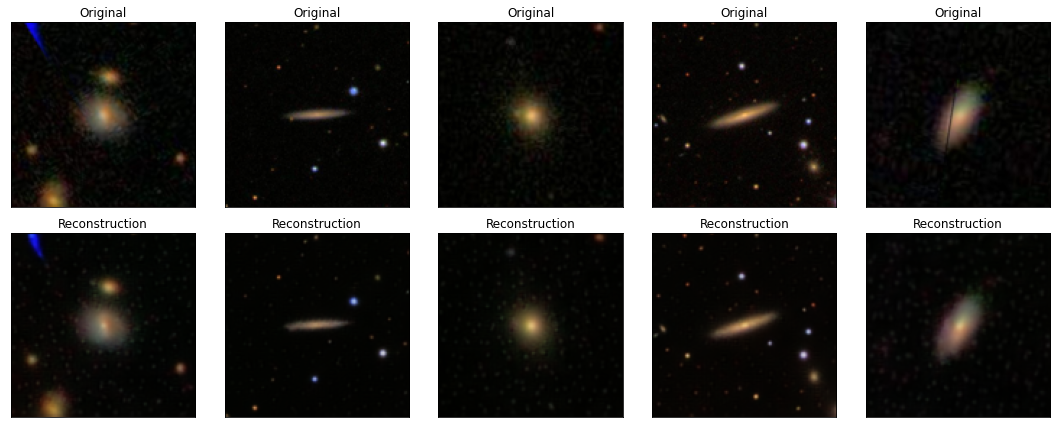

In [7]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), facecolor='white')

for i in range(5):
    ax[0][i].set_title('Original')
    ax[0][i].imshow(seen_images[i])
    ax[1][i].set_title('Reconstruction')
    ax[1][i].imshow(seen_reconstructions[i])

for row in ax:
    for figure in row:
        figure.set_xticks([])
        figure.set_yticks([])

fig.tight_layout()

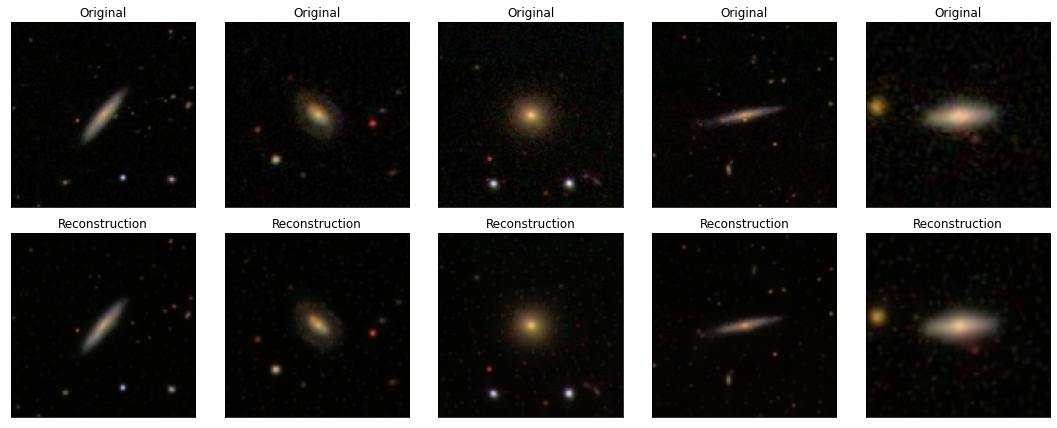

In [8]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), facecolor='white')

for i in range(5):
    ax[0][i].set_title('Original')
    ax[0][i].imshow(unseen_images[i])
    ax[1][i].set_title('Reconstruction')
    ax[1][i].imshow(unseen_reconstructions[i])

for row in ax:
    for figure in row:
        figure.set_xticks([])
        figure.set_yticks([])

fig.tight_layout()

In [4]:
def sample_vqvae(vae, device, num_samples=4):
    vae.eval()

    with torch.no_grad():
        # Get embedding info
        codebook = vae.vq.embedding.weight  # shape: [num_embeddings, embedding_dim]
        num_embeddings = vae.vq.num_embeddings
        embedding_dim = vae.vq.embedding_dim

        # Determine spatial dimensions expected by decoder
        dummy = torch.randn(1, 3, 128, 128).to(device)
        with torch.no_grad():
            z_e = vae.encoder(dummy)
            _, C, H, W = z_e.shape  # latent spatial shape

        # 1. Sample random indices
        rand_indices = torch.randint(0, num_embeddings, (num_samples, H, W), device=device)  # [B, H, W]

        # 2. Convert to embeddings
        z_q = codebook[rand_indices]  # [B, H, W, C]
        z_q = z_q.permute(0, 3, 1, 2).contiguous()  # [B, C, H, W]

        # 3. Decode
        generated = vae.decoder(z_q)  # [B, 3, 128, 128]
        return generated

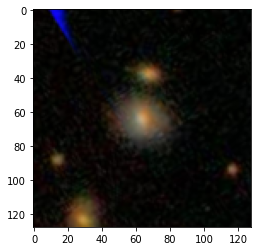

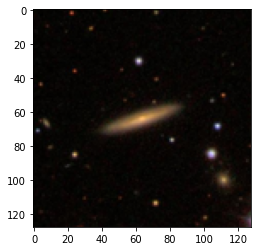

In [62]:
input_image1 = seen_images[0]
input_image2 = seen_images[3]

plt.imshow(input_image1)
plt.show()
plt.imshow(input_image2)
plt.show()

In [63]:
x, y, z = input_image1.shape
latent_image1 = model.encoder(input_image1.reshape((1, x, y, z)).permute(0, 3, 1, 2))
latent_image2 = model.encoder(input_image2.reshape((1, x, y, z)).permute(0, 3, 1, 2))
latent_image1, *_ = model.vq(latent_image1)
latent_image2, *_ = model.vq(latent_image2)

In [64]:
import numpy as np

intermediate = latent_image1

output = [model.decoder(intermediate).permute(0, 2, 3, 1).detach().cpu().numpy()[0] * 255]

for i in range(intermediate.shape[1]):
    intermediate[0, i] = latent_image2[0, i]
    output.append(model.decoder(intermediate).permute(0, 2, 3, 1).detach().cpu().numpy()[0] * 255)

output = np.array(output, dtype=np.uint8)

In [65]:
from PIL import Image

output[0]

imgs = [Image.fromarray(img) for img in output]
imgs[0].save(
    "morph.gif",
    save_all=True,
    append_images=imgs[1:],
    duration=100,
    loop=0
)


In [8]:
import pickle

def compute_code_frequencies(vae, data_loader, device='cuda'):
    """
    Run the entire dataset through the encoder and track how often each code appears.
    
    Args:
        vae: Trained VQ-VAE model
        data_loader: DataLoader with your training/validation data
        device: 'cuda' or 'cpu'
    
    Returns:
        frequencies: Tensor of shape [num_embeddings] with occurrence counts
    """
    vae.eval()
    num_embeddings = vae.vq.num_embeddings
    code_counts = torch.zeros(num_embeddings, device=device)
    
    print("Computing code frequencies...")
    with torch.no_grad():
        for batch_idx, data in enumerate(data_loader):
            print(f'Batch {batch_idx}')
            data = data.to(device)
            
            # Encode
            z_e = vae.encoder(data)
            
            # Quantize and get indices
            z_q, _, _, encoding_indices = vae.vq(z_e)
            
            # Track which codes were used
            flat_indices = encoding_indices.reshape(-1)
            code_counts.index_add_(0, flat_indices, torch.ones_like(flat_indices, dtype=torch.float32))
            
            if (batch_idx + 1) % 10 == 0:
                print(f"  Processed {batch_idx + 1} batches")
    
    # Normalize to get probabilities
    frequencies = code_counts / code_counts.sum()
    
    # Print statistics
    used_codes = (code_counts > 0).sum().item()
    print(f"\nCodebook usage: {used_codes}/{num_embeddings} codes used ({100*used_codes/num_embeddings:.1f}%)")
    print(f"Code frequency range: {code_counts.min():.0f} to {code_counts.max():.0f}")
    
    with open('frequencies.pkl', 'wb') as file:
        pickle.dump(frequencies, file)
    
    return frequencies, code_counts


def generate_images_from_frequencies(vae, frequencies, num_images=8, temperature=1.0, device='cuda'):
    """
    Generate images by sampling from the empirical code distribution.
    
    Args:
        vae: Trained VQ-VAE model
        frequencies: Probability distribution over codes [num_embeddings]
        num_images: Number of images to generate
        temperature: Controls randomness
        device: 'cuda' or 'cpu'
    
    Returns:
        images: Tensor of shape [num_images, 3, 128, 128]
    """
    vae.eval()
    
    with torch.no_grad():
        num_embeddings = vae.vq.num_embeddings
        latent_h, latent_w = 16, 16
        
        # Create logits from log probabilities, apply temperature
        logits = torch.log(frequencies + 1e-10)  # [num_embeddings]
        logits = logits / temperature
        
        # Expand to spatial dimensions
        logits = logits.unsqueeze(0).unsqueeze(0).unsqueeze(0)  # [1, 1, 1, num_embeddings]
        logits = logits.expand(num_images, latent_h, latent_w, -1)  # [B, H, W, num_embeddings]
        
        # Sample from distribution
        probs = F.softmax(logits, dim=-1)
        probs_flat = probs.reshape(-1, num_embeddings)
        sampled_flat = torch.multinomial(probs_flat, num_samples=1)
        sampled_indices = sampled_flat.reshape(num_images, latent_h, latent_w)
        
        # Decode
        flat_indices = sampled_indices.reshape(-1)
        latent_codes = vae.vq.embedding[flat_indices]
        latent_codes = latent_codes.reshape(num_images, latent_h, latent_w, -1)
        latent_codes = latent_codes.permute(0, 3, 1, 2).contiguous()
        
        images = vae.decoder(latent_codes)
        
        return images

freq, _ = compute_code_frequencies(model, train_loader, 'cpu')
generate_images_from_frequencies(model, freq, device='cpu')

Computing code frequencies...
Batch 0
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
  Processed 10 batches
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
  Processed 20 batches
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
  Processed 30 batches
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
  Processed 40 batches
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
  Processed 50 batches
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
  Processed 60 batches
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
  Processed 70 batches
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
  Processed 80 batches
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batc

tensor([[[[0.0116, 0.0089, 0.0088,  ..., 0.0205, 0.0212, 0.0215],
          [0.0094, 0.0080, 0.0081,  ..., 0.0195, 0.0205, 0.0196],
          [0.0096, 0.0084, 0.0074,  ..., 0.0192, 0.0210, 0.0185],
          ...,
          [0.0429, 0.0515, 0.0357,  ..., 0.0031, 0.0036, 0.0041],
          [0.0392, 0.0414, 0.0293,  ..., 0.0035, 0.0040, 0.0052],
          [0.0335, 0.0331, 0.0271,  ..., 0.0046, 0.0048, 0.0053]],

         [[0.0119, 0.0097, 0.0096,  ..., 0.0202, 0.0201, 0.0190],
          [0.0101, 0.0090, 0.0087,  ..., 0.0210, 0.0212, 0.0211],
          [0.0093, 0.0088, 0.0081,  ..., 0.0216, 0.0214, 0.0195],
          ...,
          [0.0443, 0.0490, 0.0317,  ..., 0.0034, 0.0037, 0.0039],
          [0.0332, 0.0348, 0.0243,  ..., 0.0033, 0.0036, 0.0041],
          [0.0283, 0.0284, 0.0230,  ..., 0.0048, 0.0040, 0.0057]],

         [[0.0044, 0.0036, 0.0034,  ..., 0.0110, 0.0121, 0.0132],
          [0.0032, 0.0029, 0.0027,  ..., 0.0115, 0.0122, 0.0122],
          [0.0027, 0.0024, 0.0021,  ..., 0